# Feature Engineering

**Project:** R2 - Bike Sharing Demand

**Team:** Angelina Bautista & Molly Scally




## Table of Contents
1. Load preprocessed data
2. Create new features (ratios, bins, interactions, log transformation)
3. Encode categorical features
4. Scale numerical features
5. Feature selection
6. Save final data for modeling

## 1. Load preprocessed data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

print(f'X_train shape: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train shape: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test shape: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test shape: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

print('\nPreview of X_train:')
display(X_train.head())

X_train shape: 13,903 rows x 53 columns
y_train shape: 13,903 rows x 1 columns
X_test shape: 3,476 rows x 53 columns
y_test shape: 3,476 rows x 1 columns

Preview of X_train:


,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
0,0.60,0.6212,0.46,0.4179,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,0.60,0.5606,0.83,0.1045,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
2,0.44,0.4394,0.94,0.0000,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False
3,0.30,0.3182,0.49,0.0000,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
4,0.12,0.1212,0.50,0.2239,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False


Below we have a summary of the columns and datatypes in `X_train`: 

In [3]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 53 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp          13903 non-null  float64
 1   atemp         13903 non-null  float64
 2   hum           13903 non-null  float64
 3   windspeed     13903 non-null  float64
 4   season_2      13903 non-null  bool   
 5   season_3      13903 non-null  bool   
 6   season_4      13903 non-null  bool   
 7   yr_1          13903 non-null  bool   
 8   mnth_2        13903 non-null  bool   
 9   mnth_3        13903 non-null  bool   
 10  mnth_4        13903 non-null  bool   
 11  mnth_5        13903 non-null  bool   
 12  mnth_6        13903 non-null  bool   
 13  mnth_7        13903 non-null  bool   
 14  mnth_8        13903 non-null  bool   
 15  mnth_9        13903 non-null  bool   
 16  mnth_10       13903 non-null  bool   
 17  mnth_11       13903 non-null  bool   
 18  mnth_12       13903 non-nu

Looks like the preprocessed data has been loaded correctly.   

- There are **13,903 rows and 53 columns in X_train**.   
- The categorical columns were converted into dummies in the last notebook. 
- The numerical features are all float, while the dummies appear to be boolean, which we will eventually convert to integer ($1/0$) format. 

Let's list each type now: 

In [4]:
# check column types
numerical_cols = X_train.select_dtypes(include=['float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='bool').columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

Numerical (4): ['temp', 'atemp', 'hum', 'windspeed']
Categorical (49): ['season_2', 'season_3', 'season_4', 'yr_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']


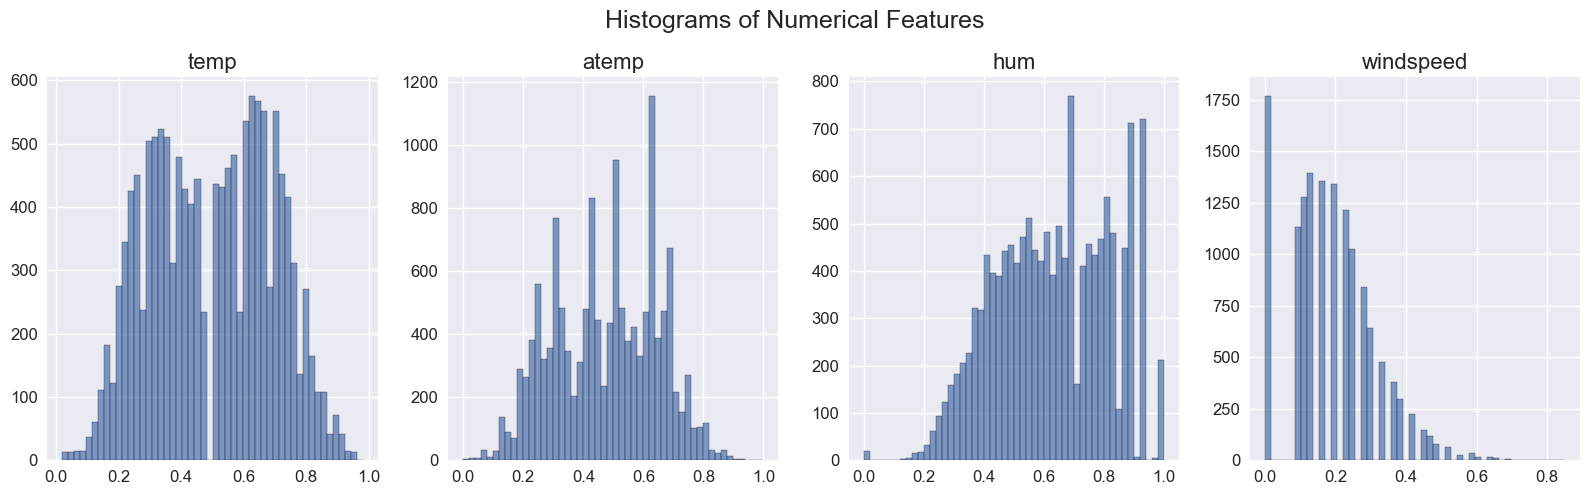

In [5]:
# histograms for numerical features
f, ax = plt.subplots(1, 4, figsize=(16, 5))
ax = ax.flatten()

for i, col in enumerate(numerical_cols):
    ax[i].hist( X_train[col], bins=50, edgecolor='black', alpha=0.7 )
    ax[i].set_title(col, fontsize=16)
    ax[i].set_xlabel('')
    ax[i].tick_params(axis='both', labelsize=12)

plt.suptitle('Histograms of Numerical Features', fontsize=18)
plt.tight_layout()
plt.savefig("../figures/03_histograms_of_numerical_features.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations 

1. Data shapes:   
- `X_train` shape: 13,903 rows x 53 columns  
- `X_test` shape: 3,476 rows x 53 columns  

2. Feature count by data type: 
- 4 numerical features  
- 49 categorical features (that is, after creating dummies, in the last notebook).
  - Originally, there were 8 categorical features. Their encoded versions all appear to be `bool` datatype and will need to be converted to $1/0$ in this notebook. 

3. Columns to engineer features on:  
- `hr_1` - `hr_23`: can bin these into broader time-of-day categories i.e. dawn/day/evening, etc  
- interaction features (feature * feature) between the above and `workingday`  
- as `atemp` takes humidity into account, we could subtract the corresponding `temp` from it to capture this humidity effect  
- interaction feature between `temp` and `windspeed`, `hum` and `windspeed`, and/or `atemp` and `windspeed`  

## 2. Create new features

### 2.1 Binary Flag - `is_dawn`, `is_morning`, `is_afternoon`, `is_evening`  

We categorize `hr_1` - `hr_23` into dawn, morning, afternoon, evening by appying the following scheme:   
- Dawn = 05:00 - 07:00 (5:00AM - 7:00AM)
- Morning = 08:00 - 11:00 (8:00AM - 11:00AM)
- Afternoon = 12:00 - 16:00 (12:00PM - 4:00PM)
- Evening = 17:00 - 19:00 (5:00PM -7 :00PM)  
- Night = 20:00 - 23:00 and 00:00 to 04:00, but is not created to avoid redundancy
  - "Night" can be interpreted as any time when all variables `is_dawn`, `is_morning`, `is_afternoon`, and `is_evening` are $0$

In [6]:
# dawn: 5:00AM - 7:00AM
X_train["is_dawn"] = X_train[[f"hr_{i}" for i in range(5, 8)]].any(axis=1).astype(int)
X_test["is_dawn"] = X_test[[f"hr_{i}" for i in range(5, 8)]].any(axis=1).astype(int)

# morning: 8:00AM - 11:00AM
X_train["is_morning"] = X_train[[f"hr_{i}" for i in range(8, 12)]].any(axis=1).astype(int)
X_test["is_morning"] = X_test[[f"hr_{i}" for i in range(8, 12)]].any(axis=1).astype(int)

# afternoon: 12:00PM - 4:00PM
X_train["is_afternoon"] = X_train[[f"hr_{i}" for i in range(12, 17)]].any(axis=1).astype(int)
X_test["is_afternoon"] = X_test[[f"hr_{i}" for i in range(12, 17)]].any(axis=1).astype(int)

# evening: 5:00PM -7 :00PM
X_train["is_evening"] = X_train[[f"hr_{i}" for i in range(17, 20)]].any(axis=1).astype(int)
X_test["is_evening"] = X_test[[f"hr_{i}" for i in range(17, 20)]].any(axis=1).astype(int)

# night: remaining hours of 20-23 + 0-4; redundant 

### 2.2 Interaction - `rush_hour`

This would aim to capture elevated bike demand during the 5-7PM time on working days only. 

Defined as `is_evening` x `workingday_1`: 

In [7]:
X_train["rush_hour"] = X_train["is_evening"] * X_train["workingday_1"]
X_test["rush_hour"] = X_test["is_evening"] * X_test["workingday_1"]

### 2.3 Binary Flag - `temp_extreme`, `atemp_extreme`, `hum_extreme`, `windspeed_extreme`

Flags for extremes in the range of each environmental feature.  

Each of these becomes $1$ for any point at which it either falls below the 10th percentile or exceeds the 90th percentile of its underlying numerical feature's range.  

In [8]:
for col in ["temp", "atemp", "hum", "windspeed"]:
    low_thresh = X_train[col].quantile(0.1)
    high_thresh = X_train[col].quantile(0.9)

    X_train[f"{col}_extreme"] = (
        (X_train[col] <= low_thresh) | (X_train[col] >= high_thresh)
    ).astype(int)

    X_test[f"{col}_extreme"] = (
        (X_test[col] <= low_thresh) | (X_train[col] >= high_thresh)
    ).astype(int)

### 2.4 Interaction - `temp_diff` 

This feature aims to capture the effect of humidity, i.e. the relative difference between simply the `temp` and `atemp` (which, as the ncorporates humidity to form the "feels like")

In [9]:
X_train['temp_diff'] = X_train['atemp'] - X_train['temp']
X_test['temp_diff'] = X_test['atemp'] - X_test['temp']

### 2.5 Interaction - `temp_windspeed`

This feature is the interaction between `temp` and `windspeed`. The aim of including this would be to capture any additional effect on rental count that could be present at particular windspeeds.  

In [10]:
X_train["temp_windspeed"] = X_train["temp"] * X_train["windspeed"]
X_test["temp_windspeed"] = X_test["temp"] * X_test["windspeed"]

### 2.6 Interaction - `hum_windspeed`

Similar to above

In [11]:
X_train["hum_windspeed"] = X_train["hum"] * X_train["windspeed"]
X_test["hum_windspeed"] = X_test["hum"] * X_test["windspeed"]

In [12]:
# confirm value counts
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 65 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temp               13903 non-null  float64
 1   atemp              13903 non-null  float64
 2   hum                13903 non-null  float64
 3   windspeed          13903 non-null  float64
 4   season_2           13903 non-null  bool   
 5   season_3           13903 non-null  bool   
 6   season_4           13903 non-null  bool   
 7   yr_1               13903 non-null  bool   
 8   mnth_2             13903 non-null  bool   
 9   mnth_3             13903 non-null  bool   
 10  mnth_4             13903 non-null  bool   
 11  mnth_5             13903 non-null  bool   
 12  mnth_6             13903 non-null  bool   
 13  mnth_7             13903 non-null  bool   
 14  mnth_8             13903 non-null  bool   
 15  mnth_9             13903 non-null  bool   
 16  mnth_10            139

### Observations

Summarized list of features created and why:

- `is_dawn`, `is_morning`, `is_afternoon`, `is_evening`: Categorical flags that indicate the time of day. These help the model learn patterns that vary by time (e.g. bike rentals being higher in the morning or evening).
- `rush_hour`: Binary feature marking peak commuting hours (5–7 PM on working days). This helps the model capture peaks in bike rentals due to predictable daily traffic patterns.
- `temp_extreme`, `atemp_extreme`, `hum_extreme`, `windspeed_extreme`: Flags for unusually high or low temperature, “feels-like” temperature, humidity, or wind speed. These help the model detect outliers that may influence user behavior (e.g. fewer rentals during extreme heat or strong winds).
- `temp_diff`: Difference between actual temperature and “feels-like” temperature (`temp` - `atemp`). Helps the model account for perceived comfort, which can affect activity levels and in turn, bike rentals.
- `temp_windspeed`, `hum_windspeed`: Interaction features combining temperature & windspeed and humidity & windspeed, respectively. These capture compounded effects (e.g., a warm but very windy day may reduce rentals more than either factor alone).

## 3. Encode categorical columns

### 3.1 Binary Mapping

After creating new features in the last stage, let's get counts of each datatype (bool vs integer): 

In [13]:
# check datatypes of categorical columns
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
int_cols = X_train.select_dtypes(include=['int64']).columns.tolist()

print(f'Boolean ({len(bool_cols)}): {bool_cols}')
print(f'Integer ({len(int_cols)}): {int_cols}')

Boolean (49): ['season_2', 'season_3', 'season_4', 'yr_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']
Integer (9): ['is_dawn', 'is_morning', 'is_afternoon', 'is_evening', 'rush_hour', 'temp_extreme', 'atemp_extreme', 'hum_extreme', 'windspeed_extreme']


Now, the boolean columns are transformed from True/False to 1/0: 

In [14]:
X_train[bool_cols] = X_train[bool_cols].apply(lambda col: col.map({True: 1, False: 0}))
X_test[bool_cols] = X_test[bool_cols].apply(lambda col: col.map({True: 1, False: 0}))

Now, we recheck. We should observe that all 49 categorical features are now integer, with zero boolean. 

In [15]:
# recheck categorical column data types
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
int_cols = X_train.select_dtypes(include=['int64']).columns.tolist()

print(f'Boolean ({len(bool_cols)}): {bool_cols}')
print(f'Integer ({len(int_cols)}): {int_cols}')

Boolean (0): []
Integer (58): ['season_2', 'season_3', 'season_4', 'yr_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_1', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'is_dawn', 'is_morning', 'is_afternoon', 'is_evening', 'rush_hour', 'temp_extreme', 'atemp_extreme', 'hum_extreme', 'windspeed_extreme']


Finally, let's store this column list `int_cols` under a new name `categorical_cols` for clarity in the following steps: 

In [16]:
categorical_cols = int_cols

In [17]:
# verify there are no remaining object datatype columns (features)
object_cols = X_train.select_dtypes(include='object')

print(f'Object ({len(object_cols)}): {object_cols}')

Object (13903): Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[13903 rows x 0 columns]


In [18]:
print(f'The dataset contains {X_train.shape[0]} rows and {X_train.shape[1]} columns.')

The dataset contains 13903 rows and 65 columns.


### Observations 

- When checking data types, 49 boolean variables remained, due to dummy variables being created in the data preprocessing notebook. 
- Because of this, binary mapping was used on the remaining boolean features. 
- As indicated above, after encoding the categorical columns, there are 65 total columns ready to use for modeling. 

## 4. Scale numerical features

First let's get an updated list of the numerical features list after we created the new features. 

In [19]:
numerical_cols = X_train.select_dtypes(include=['float64']).columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')

Numerical (7): ['temp', 'atemp', 'hum', 'windspeed', 'temp_diff', 'temp_windspeed', 'hum_windspeed']


Let's take a look at the ranges of these features: 

In [20]:
# check ranges before scaling
print("Feature ranges BEFORE scaling:\n")
print(X_train[numerical_cols].describe().loc[['min', 'max']].round(2))

Feature ranges BEFORE scaling:

     temp  atemp  hum  windspeed  temp_diff  temp_windspeed  hum_windspeed
min  0.02    0.0  0.0       0.00      -0.62            0.00           0.00
max  0.98    1.0  1.0       0.85       0.09            0.68           0.57


One thing to note is that the original numerical features `temp`, `atemp`, `hum`, and `windspeed` are actually already very similar in scale. 

In [21]:
# get subsets of the categorical columns (which we leave out of the scaling procedure)
X_train_categorical = X_train[categorical_cols]
X_test_categorical = X_test[categorical_cols]

# apply scaling
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train[numerical_cols])
X_test_standard = scaler.transform(X_test[numerical_cols])

X_train_standard = pd.DataFrame(X_train_standard, columns=numerical_cols, index=X_train.index)
X_test_standard = pd.DataFrame(X_test_standard, columns=numerical_cols, index=X_test.index)

# reattach the unscaled binary dummies
X_train_standard[categorical_cols] = X_train[categorical_cols]
X_test_standard[categorical_cols]  = X_test[categorical_cols]

print('Scaling complete')
print(f'\n Sample mean (should be ~0 for train):')
print(X_train_standard.mean().round(4).head())
print(f'\n Sample stds (should be ~1 for train):')
print(X_test_standard.std().round(4).head())

Scaling complete

 Sample mean (should be ~0 for train):
temp         0.0
atemp       -0.0
hum         -0.0
windspeed   -0.0
temp_diff    0.0
dtype: float64

 Sample stds (should be ~1 for train):
temp         0.9991
atemp        1.0006
hum          1.0071
windspeed    1.0155
temp_diff    1.1094
dtype: float64


We can also confirm visually the change in scaling via each variable's histogram: 

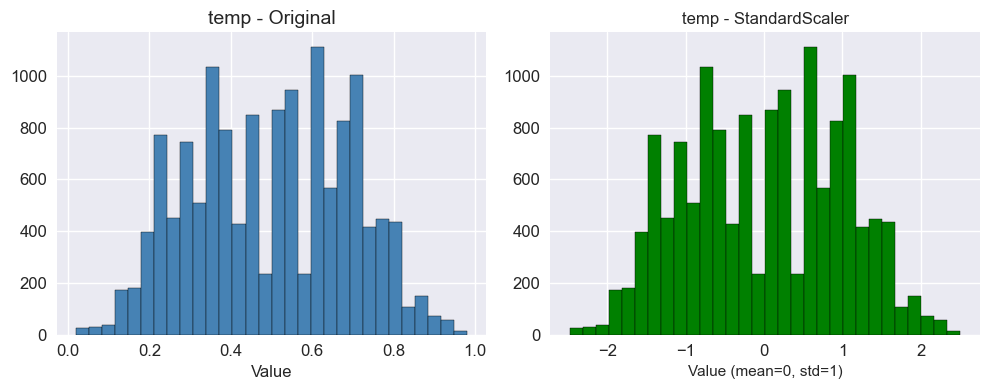

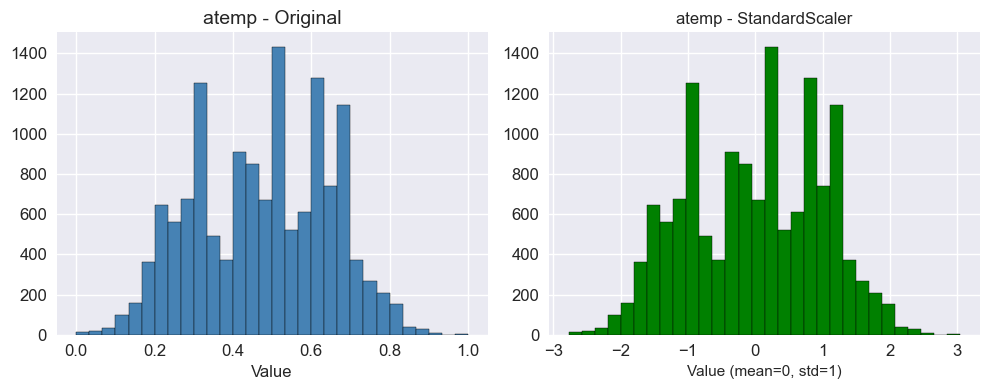

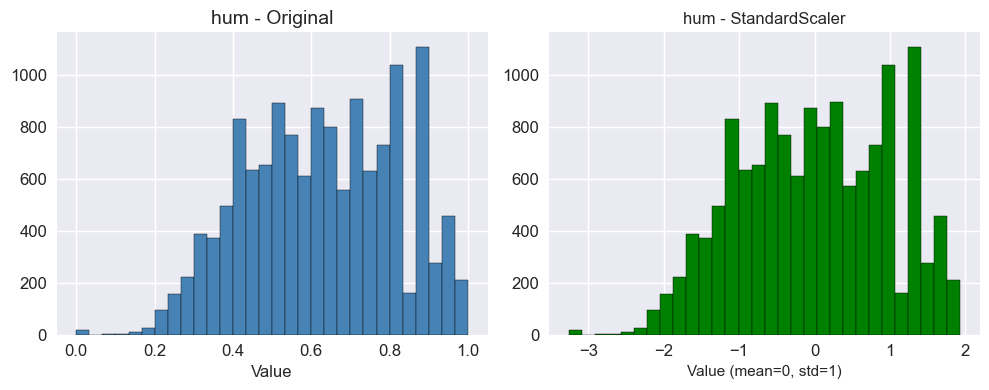

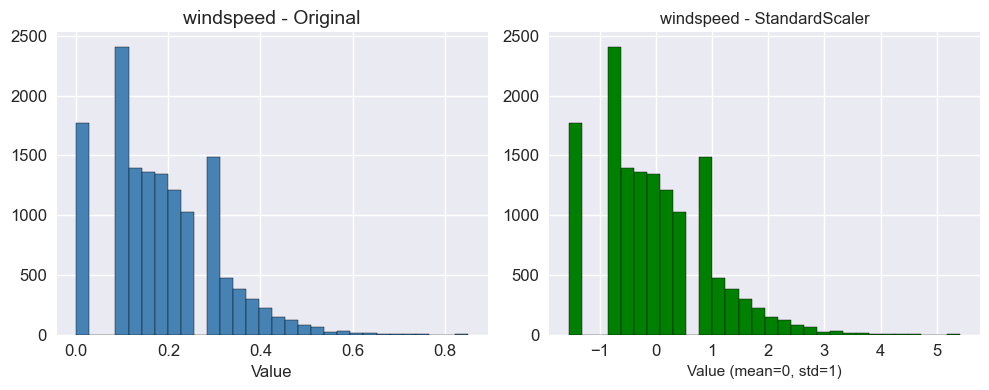

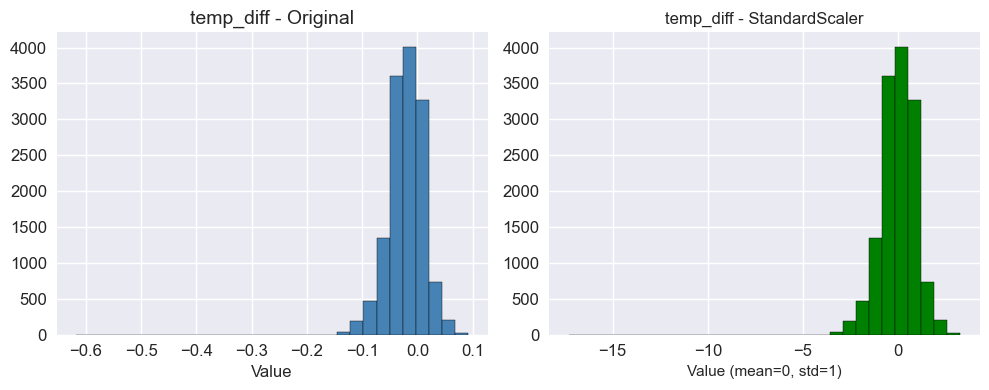

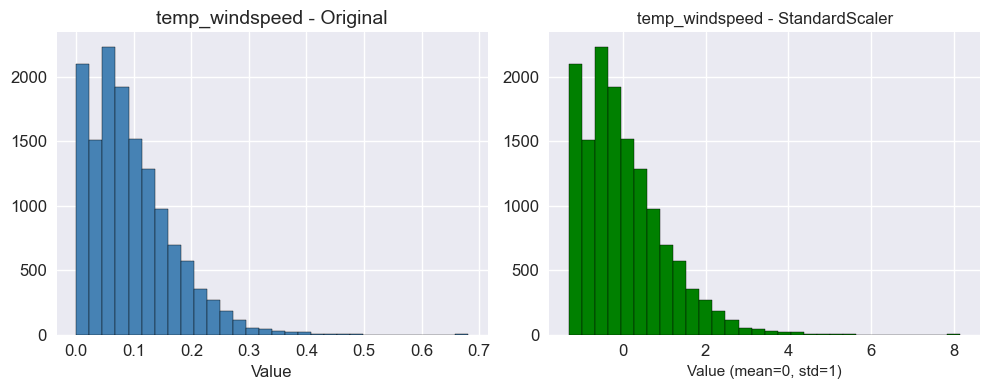

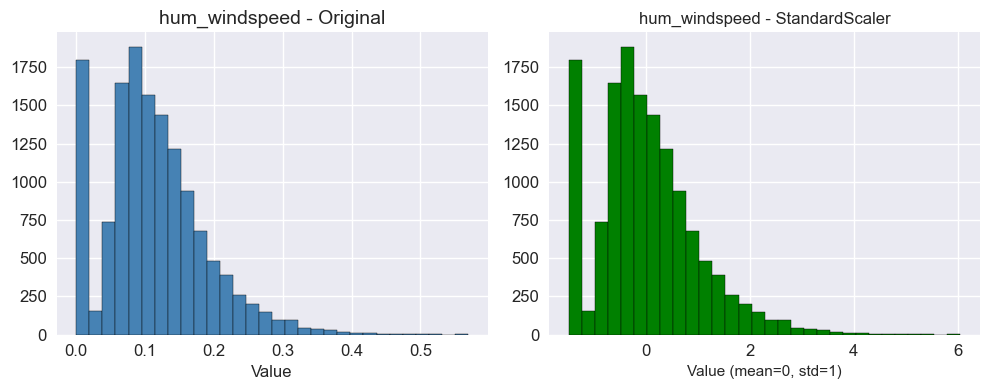

In [22]:
# compare before/after for each numerical variable
for feature in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(X_train[feature], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title(f'{feature} - Original', fontsize=14)
    axes[0].set_xlabel('Value', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=12)

    axes[1].hist(X_train_standard[feature], bins=30, color='green', edgecolor='black')
    axes[1].set_title(f'{feature} - StandardScaler')
    axes[1].set_xlabel('Value (mean=0, std=1)')
    axes[1].tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.savefig(f"../figures/03_{feature}_before_after_scaling.png", dpi=300, bbox_inches="tight")
    plt.show()

### Observations

- All remaining numerical features were scaled - fit_transform for `X_train` and transform on `X_test`
  - The ranges for all numerical columns were checked and it was taken into notice that the original numerical variables were already similar in scale.
- Refer to cell 21 for confirmation that training column means are approximately 0.

## 5. Feature selection

Now we will investigate the quality of the feature set.  

Correlation analysis will follow, allowing us to look for: 
- unehelpful features (which would display low correlation with the target `cnt`)
- redundant features (which would show up as being highly correlated with other features, pointing to multicollinearity)

First, we simply calculate the Pearson correlation coefficient between each feature and `cnt`, and look at the top and bottom 10 (as opposed to the full list, as there are 65 features). Those with the highest correlation to `cnt` are displayed at the top and are listed in descending order from there. 

In [23]:
correlation_matrix = pd.concat([X_train_standard, y_train],axis=1).corr()

correlations = correlation_matrix['cnt'].abs().sort_values(ascending=False)
correlations = correlations.drop('cnt')

print('Top 10 features correlated with target:')
print(correlations.head(10).round(4))

print(f'\nBottom 10:')
print(correlations.tail(10).round(4))

Top 10 features correlated with target:
rush_hour         0.4513
is_evening        0.4386
temp              0.4021
atemp             0.3990
hum               0.3225
hr_17             0.3185
temp_windspeed    0.3021
hr_18             0.2683
temp_diff         0.2578
yr_1              0.2484
Name: cnt, dtype: float64

Bottom 10:
hr_10            0.0164
weekday_5        0.0160
weekday_1        0.0093
weekday_3        0.0066
weathersit_4     0.0059
weekday_6        0.0047
mnth_4           0.0036
atemp_extreme    0.0033
hum_extreme      0.0025
weekday_2        0.0009
Name: cnt, dtype: float64


It seems that the most predictive features according to correlation are: 
- `rush_hour` ($r=0.4513$)
- `is_evening` ($r=0.4386$)
- `temp` ($r=0.4021$)
- `atemp` ($r=0.3990$)
- `hum` ($r=0.3225$)
- `hr_17` ($r=0.3185$)

The least correlated are `weekday_2` ($r=0.0009$), `hum_extreme` ($r=0.0025$), `atemp_extreme` ($r=0.0033$), and up from there.  

Here are those top features visualized: 

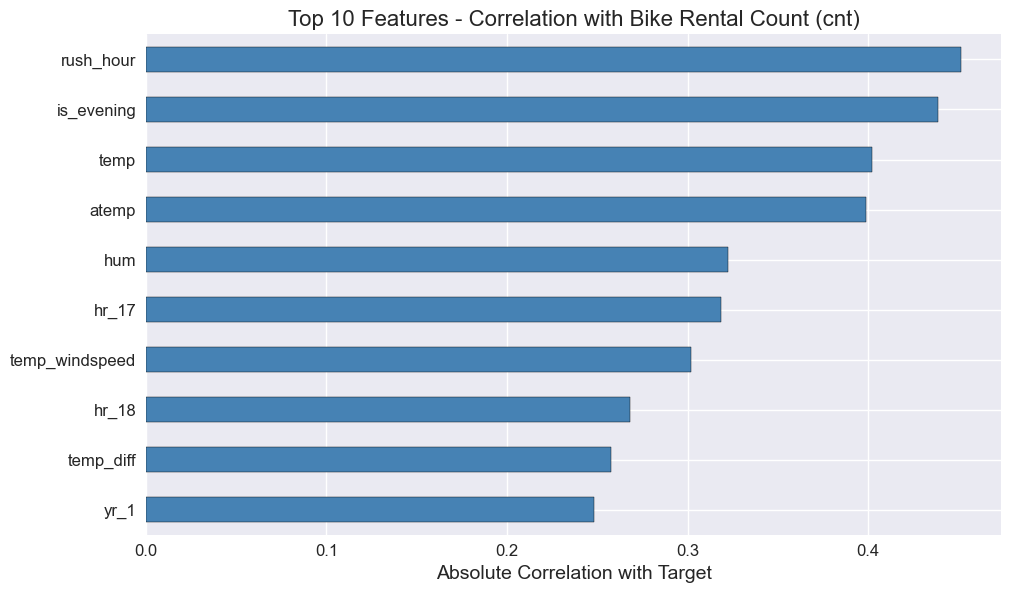

In [24]:
# visualize top 10 feature correlations with target
top10 = correlations.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh', color='steelblue',edgecolor='black')
plt.xlabel('Absolute Correlation with Target', fontsize=14)
plt.title('Top 10 Features - Correlation with Bike Rental Count (cnt)', fontsize=16)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig("../figures/03_top10features_correlation_with_cnt.png", dpi=300, bbox_inches="tight")
plt.show()

Now we look at correlations between features. 

There are several comments we can make without even looking at the numbers: 
- Several of the engineered features, e.g. `rush_hour`, `is_evening`, and `hr_17`, will all contain some of the same information. This is because `hr_17` was used to create `is_evening`, and `is_evening` was used to create `rush_hour`. 
- Several variables that were not engineered, but original to the dataset, also contain some of the same info. E.g., as we already noted in the EDA, `temp` and `atemp` (temperature and "feels like" temperature) track together. This is because the "feels like" takes humidity (`hum`) into account. So, we should eventually choose to use EITHER `temp` + `hum` OR `atemp` alone, but not all three. 

In [25]:
# find pairs with absolute correlation > 0.8
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.8):")
high_corr_df.sort_values(by='Feature 1')


Highly correlated feature pairs (>0.8):


,Feature 1,Feature 2,Correlation
2,is_evening,rush_hour,0.809634
0,temp,atemp,0.988539
3,temp_extreme,atemp_extreme,0.807432
1,windspeed,hum_windspeed,0.816640


As expected, we see `is_evening` and `rush_hour` along with `temp` and `atemp` (and the "extreme" flags which we engineered).

We also see high correlation between `windspeed` and its interaction with `hum`.  

For now, we will make no changes to the feature set. We will conduct a fuller feature selection during the modeling process. At that time, we'll decide which variable in highly-correlated pairs should remain. 

### Observations

1. Top 3 features most correlated with the target
- `rush_hour`: $r=0.4513$
- `is_evening`: $r=0.4386$
- `temp`: $r=0.4021$

2. Engineered features that outperformed the raw columns they came from
- `rush_hour`: captures the combined effect of peak commuting hours, whereas the raw hour columns only show the effect for their respective individual hours. This aggregation creates a stronger, more meaningful signal for the model
- `temp_diff`: the difference feature quantifies perceived comfort, which seems more predictive than just flagging extreme temperatures `temp` and `atemp`

3. High-correlation pairs found
- `temp`, `atemp`, `hum`: only one will be chosen and remaining will be dropped in the case of the linear models to ensure a lowered risk of multicollinearity
- Multiple cases of newly-correlated features resulting from our feature engineering: e.g. `rush_hour`, `is_evening`, `hr_17`: in these cases, having all three might be redundant if used in a linear model. 

## 6. Save final data for modeling

In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 65 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temp               13903 non-null  float64
 1   atemp              13903 non-null  float64
 2   hum                13903 non-null  float64
 3   windspeed          13903 non-null  float64
 4   season_2           13903 non-null  int64  
 5   season_3           13903 non-null  int64  
 6   season_4           13903 non-null  int64  
 7   yr_1               13903 non-null  int64  
 8   mnth_2             13903 non-null  int64  
 9   mnth_3             13903 non-null  int64  
 10  mnth_4             13903 non-null  int64  
 11  mnth_5             13903 non-null  int64  
 12  mnth_6             13903 non-null  int64  
 13  mnth_7             13903 non-null  int64  
 14  mnth_8             13903 non-null  int64  
 15  mnth_9             13903 non-null  int64  
 16  mnth_10            139

In [27]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3476 entries, 0 to 3475
Data columns (total 65 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temp               3476 non-null   float64
 1   atemp              3476 non-null   float64
 2   hum                3476 non-null   float64
 3   windspeed          3476 non-null   float64
 4   season_2           3476 non-null   int64  
 5   season_3           3476 non-null   int64  
 6   season_4           3476 non-null   int64  
 7   yr_1               3476 non-null   int64  
 8   mnth_2             3476 non-null   int64  
 9   mnth_3             3476 non-null   int64  
 10  mnth_4             3476 non-null   int64  
 11  mnth_5             3476 non-null   int64  
 12  mnth_6             3476 non-null   int64  
 13  mnth_7             3476 non-null   int64  
 14  mnth_8             3476 non-null   int64  
 15  mnth_9             3476 non-null   int64  
 16  mnth_10            3476 

In [28]:
print(f'There are {X_train.isnull().sum().sum()} missing values in the training dataset.')
print(f'There are {X_test.isnull().sum().sum()} missing values in the test dataset.')

There are 0 missing values in the training dataset.
There are 0 missing values in the test dataset.


In [29]:
training_cols = X_train.select_dtypes(include='object')
testing_cols = X_test.select_dtypes(include='object')

print(f'Object ({len(training_cols)}): {training_cols}')
print(f'Object ({len(testing_cols)}): {testing_cols}')

Object (13903): Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[13903 rows x 0 columns]
Object (3476): Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[3476 rows x 0 columns]


In [30]:
import os

os.makedirs('../data/modeling', exist_ok=True)

# save unscaled (for tree models)
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)
y_train.to_csv('../data/modeling/y_train.csv', index=False)
y_test.to_csv('../data/modeling/y_test.csv', index=False)

# save scaled (for linear models)
X_train_standard.to_csv('../data/modeling/X_train_standard.csv', index=False)
X_test_standard.to_csv('../data/modeling/x_test_standard.csv', index=False)


print("Data saved!")
print(f"  train_engineered.csv: {X_train.shape[1]} columns (unscaled)")
print(f"  train_scaled.csv: {X_train_standard.shape[1]} columns (scaled)")

Data saved!
  train_engineered.csv: 65 columns (unscaled)
  train_scaled.csv: 65 columns (scaled)


### Observations

- It is verified that the training and testing datasets have the same columns in the same order.
- It is confirmed that there are no missing values in both datasets.
- It is checked that there are no object-type columns remain.

## Key Findings Summary

There were 12 features originally: `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, and `windspeed`. 

One-hot encoding was applied in the last notebook for the 8 originally categorical features: `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, and `weathersit`. These 8 original feature columns were removed after encoding. This brought the total number of categorical features to 49. 

### Features created:  

Features engineered in this notebook include: `is_dawn`, `is_morning`, `is_afternoon`, `is_evening`, `rush_hour`, `temp_extreme`, `atemp_extreme`, `hum_extreme`, `windspeed_extreme`, `temp_diff`, `temp_windspeed`, and `hum_windspeed`.  

### Processing applied: 
- One-hot encoding (see last notebook): `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, and `weathersit`
- Standard scaling: all numerical features (`temp`, `atemp`, `hum`, `windspeed`, `temp_diff`, `temp_windspeed`, `hum_windspeed`)

### Datasets: 
- **X_train/y_train** original unscaled dataset
- **X_train_standard/y_train_standard** scaled dataset for linear models
- **X_test/y_test** untouched test sets for final evaluation